In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd

df = pd.read_csv("/content/sample_data/USA_Housing.csv")

print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print(df.columns)

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [6]:
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv("/content/sample_data/USA_Housing.csv")

# 2. Select the target column
y = df["Price"]

# 3. Select input features
# Remove Address because it is not useful for the model
# Add/remove features based on your EDA findings
X = df.drop(columns=["Price", "Address"])


# 4. Split into Training (60%) and Remaining (40%)
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

# 5. Split remaining data into Validation (20%) and Test (20%)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.5,
    random_state=42
)

# 6. Check dataset sizes
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_validation)}")
print(f"Test samples: {len(X_test)}")

Training samples: 3000
Validation samples: 1000
Test samples: 1000


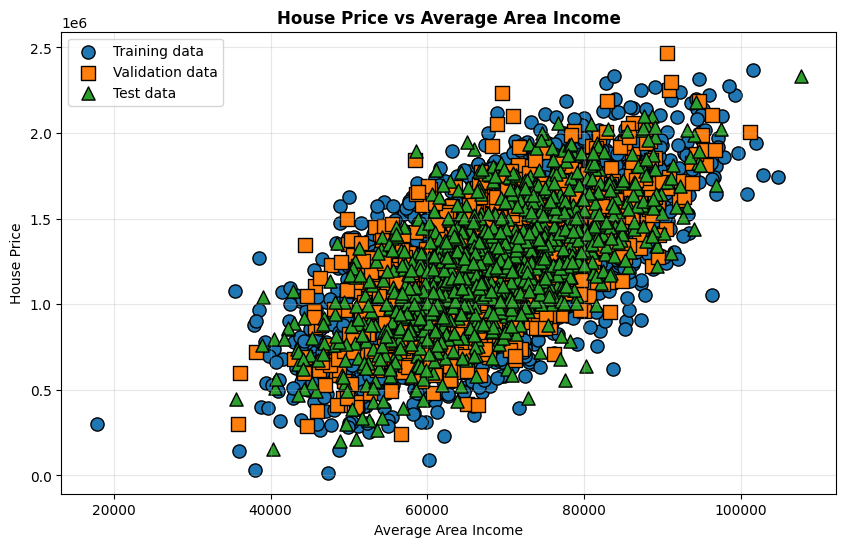

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Training data
plt.scatter(
    X_train["Avg. Area Income"],
    y_train,
    s=90,
    edgecolors="black",
    label="Training data"
)

# Validation data
plt.scatter(
    X_validation["Avg. Area Income"],
    y_validation,
    s=90,
    marker="s",
    edgecolors="black",
    label="Validation data"
)

# Test data
plt.scatter(
    X_test["Avg. Area Income"],
    y_test,
    s=90,
    marker="^",
    edgecolors="black",
    label="Test data"
)

plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("House Price vs Average Area Income", fontweight="bold")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

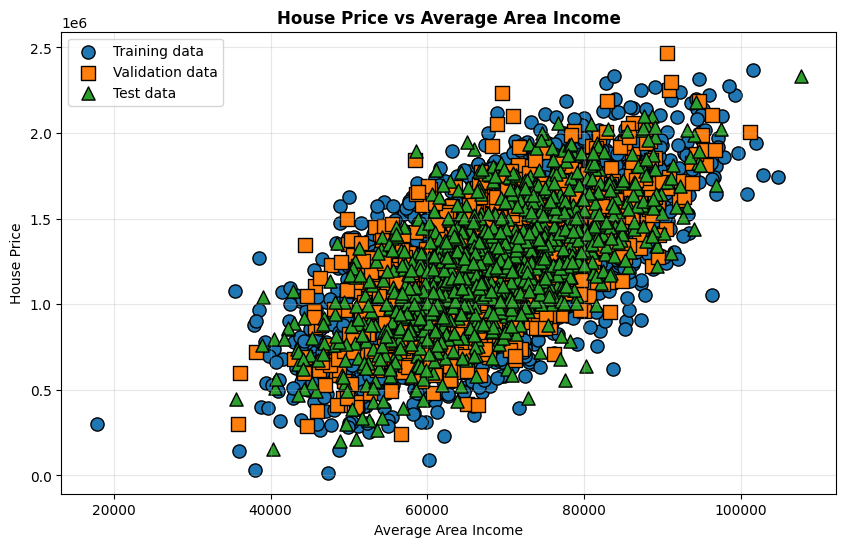

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Training data
plt.scatter(
    X_train["Avg. Area Income"],
    y_train,
    s=90,
    edgecolors="black",
    label="Training data"
)

# Validation data
plt.scatter(
    X_validation["Avg. Area Income"],
    y_validation,
    s=90,
    marker="s",
    edgecolors="black",
    label="Validation data"
)

# Test data
plt.scatter(
    X_test["Avg. Area Income"],
    y_test,
    s=90,
    marker="^",
    edgecolors="black",
    label="Test data"
)

plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("House Price vs Average Area Income", fontweight="bold")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_train_pred = linear_model.predict(X_train)
linear_val_pred = linear_model.predict(X_validation)

print(f"Training MSE: {mean_squared_error(y_train, linear_train_pred):.4f}")
print(f"Validation MSE: {mean_squared_error(y_validation, linear_val_pred):.4f}")
print(f"Validation R²: {r2_score(y_validation, linear_val_pred):.4f}")

Training MSE: 10292121830.7142
Validation MSE: 10435054798.0002
Validation R²: 0.9102


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create the pipeline
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Fit ONLY on training data
linear_pipeline.fit(X_train, y_train)

# Predictions
train_pred = linear_pipeline.predict(X_train)
val_pred = linear_pipeline.predict(X_validation)
test_pred = linear_pipeline.predict(X_test)

# Evaluate Training data
train_mse = mean_squared_error(y_train, train_pred)
train_r2 = r2_score(y_train, train_pred)

# Evaluate Validation data
val_mse = mean_squared_error(y_validation, val_pred)
val_r2 = r2_score(y_validation, val_pred)

# Evaluate Test data
test_mse = mean_squared_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Training MSE:   {train_mse:.4f}")
print(f"Training R²:    {train_r2:.4f}")

print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation R²:  {val_r2:.4f}")

print(f"Test MSE:       {test_mse:.4f}")
print(f"Test R²:        {test_r2:.4f}")

Training MSE:   10292121830.7142
Training R²:    0.9189
Validation MSE: 10435054797.9996
Validation R²:  0.9102
Test MSE:       9804414953.3056
Test R²:        0.9222


NameError: name 'X_plot' is not defined

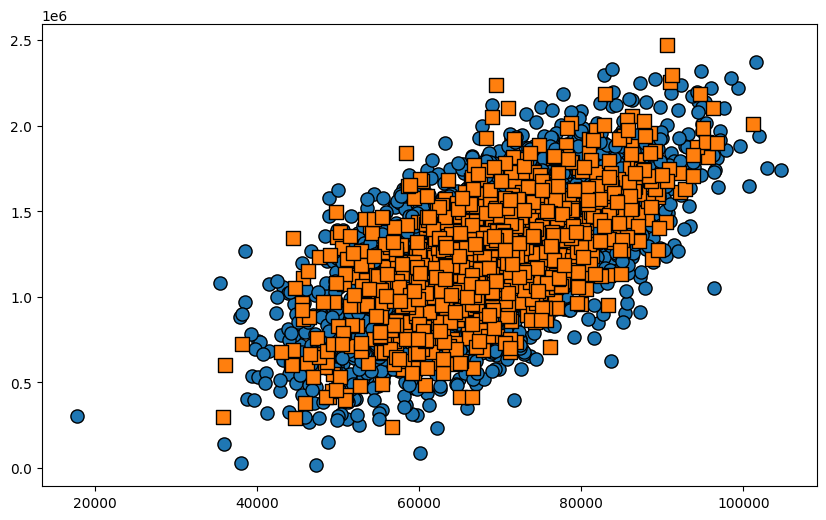

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(X_train["Avg. Area Income"], y_train, s=90, edgecolors="black", label="Training data")
plt.scatter(X_validation["Avg. Area Income"], y_validation, s=90, marker="s", edgecolors="black", label="Validation data")
plt.plot(X_plot["Avg. Area Income"], linear_model.predict(X_plot), color="red", linewidth=3, label="Linear model")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Underfits Curved Data", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

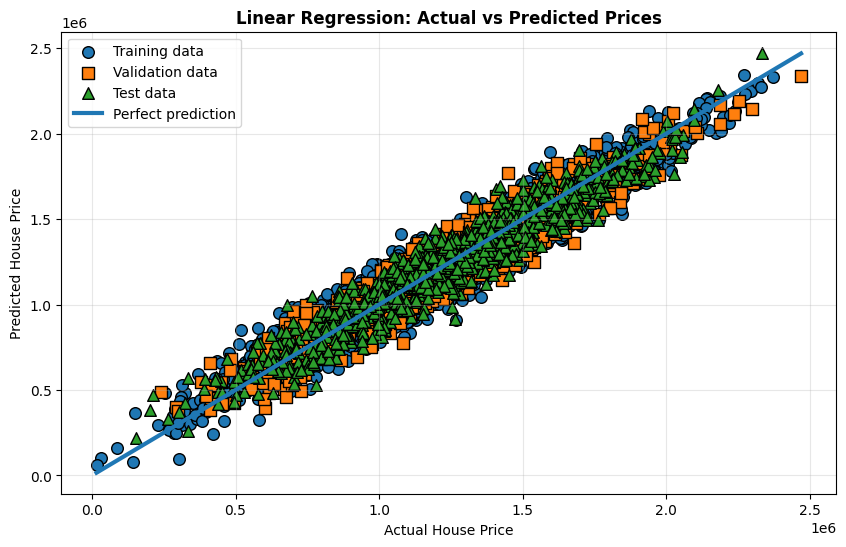

In [14]:
import matplotlib.pyplot as plt

# Make predictions
train_pred = linear_model.predict(X_train)
val_pred = linear_model.predict(X_validation)
test_pred = linear_model.predict(X_test)

plt.figure(figsize=(10, 6))

# Training predictions
plt.scatter(
    y_train,
    train_pred,
    s=70,
    edgecolors="black",
    label="Training data"
)

# Validation predictions
plt.scatter(
    y_validation,
    val_pred,
    s=70,
    marker="s",
    edgecolors="black",
    label="Validation data"
)

# Test predictions
plt.scatter(
    y_test,
    test_pred,
    s=70,
    marker="^",
    edgecolors="black",
    label="Test data"
)

# Perfect prediction line
min_price = min(y_train.min(), y_validation.min(), y_test.min())
max_price = max(y_train.max(), y_validation.max(), y_test.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linewidth=3,
    label="Perfect prediction"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Linear Regression: Actual vs Predicted Prices", fontweight="bold")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_train.ravel(), y_train, s=90, edgecolors="black", label="Training data")
plt.scatter(X_validation.ravel(), y_validation, s=90, marker="s", edgecolors="black", label="Validation data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Noisy Nonlinear Data", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

AttributeError: 'DataFrame' object has no attribute 'ravel'

<Figure size 1000x600 with 0 Axes>

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_train_pred = linear_model.predict(X_train)
linear_val_pred = linear_model.predict(X_validation)

print(f"Training MSE: {mean_squared_error(y_train, linear_train_pred):.4f}")
print(f"Validation MSE: {mean_squared_error(y_validation, linear_val_pred):.4f}")
print(f"Validation R²: {r2_score(y_validation, linear_val_pred):.4f}")

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train.ravel(), y_train, s=90, edgecolors="black", label="Training data")
plt.scatter(X_validation.ravel(), y_validation, s=90, marker="s", edgecolors="black", label="Validation data")
plt.plot(X_plot.ravel(), linear_model.predict(X_plot), color="red", linewidth=3, label="Linear model")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Underfits Curved Data", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

AttributeError: 'DataFrame' object has no attribute 'ravel'

<Figure size 1000x600 with 0 Axes>

**Polynomial Features**

In [17]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

feature_demo = PolynomialFeatures(
    degree=3,
    include_bias=False
)

# Transform first 5 rows of X
X_demo = feature_demo.fit_transform(X[:5])

print("Generated features:")

# Use the actual column names
print(feature_demo.get_feature_names_out(X.columns))

print("\nFirst five transformed rows:")
print(np.round(X_demo, 4))

Generated features:
['Avg. Area Income' 'Avg. Area House Age' 'Avg. Area Number of Rooms'
 'Avg. Area Number of Bedrooms' 'Area Population' 'Avg. Area Income^2'
 'Avg. Area Income Avg. Area House Age'
 'Avg. Area Income Avg. Area Number of Rooms'
 'Avg. Area Income Avg. Area Number of Bedrooms'
 'Avg. Area Income Area Population' 'Avg. Area House Age^2'
 'Avg. Area House Age Avg. Area Number of Rooms'
 'Avg. Area House Age Avg. Area Number of Bedrooms'
 'Avg. Area House Age Area Population' 'Avg. Area Number of Rooms^2'
 'Avg. Area Number of Rooms Avg. Area Number of Bedrooms'
 'Avg. Area Number of Rooms Area Population'
 'Avg. Area Number of Bedrooms^2'
 'Avg. Area Number of Bedrooms Area Population' 'Area Population^2'
 'Avg. Area Income^3' 'Avg. Area Income^2 Avg. Area House Age'
 'Avg. Area Income^2 Avg. Area Number of Rooms'
 'Avg. Area Income^2 Avg. Area Number of Bedrooms'
 'Avg. Area Income^2 Area Population'
 'Avg. Area Income Avg. Area House Age^2'
 'Avg. Area Income Avg. Are

In [18]:
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(PolynomialFeatures(degree=4, include_bias=False), LinearRegression())

poly_model.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=4, include_bias=False)),
                ('linearregression', LinearRegression())])

In [19]:
poly_train_pred = poly_model.predict(X_train)
poly_val_pred = poly_model.predict(X_validation)

print(f"Training MSE: {mean_squared_error(y_train, poly_train_pred):.4f}")
print(f"Validation MSE: {mean_squared_error(y_validation, poly_val_pred):.4f}")
print(f"Validation R²: {r2_score(y_validation, poly_val_pred):.4f}")

Training MSE: 10321092615.9742
Validation MSE: 10738690273.5161
Validation R²: 0.9076


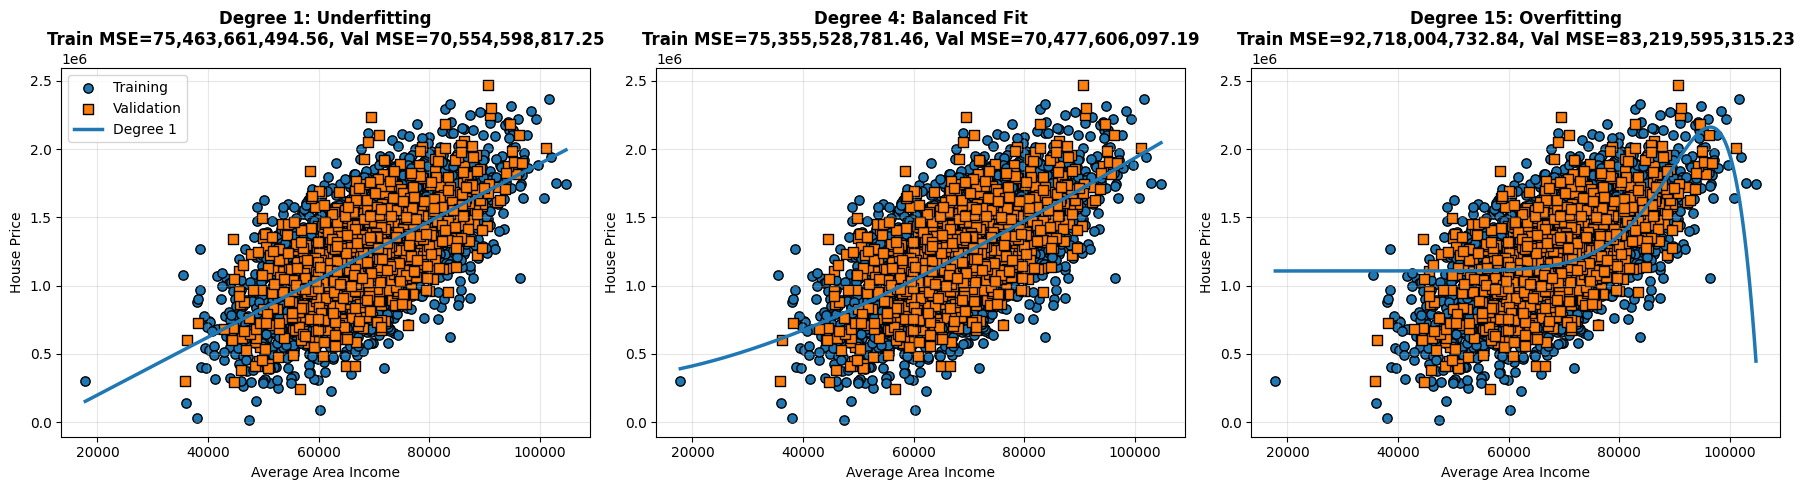

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Use ONE feature for polynomial curve visualization
feature = "Avg. Area Income"

X_train_1 = X_train[[feature]]
X_validation_1 = X_validation[[feature]]

# Values for drawing the curves
X_plot = pd.DataFrame({
    feature: np.linspace(
        X_train_1[feature].min(),
        X_train_1[feature].max(),
        300
    )
})

degrees_to_compare = [1, 4, 15]
degree_labels = ["Underfitting", "Balanced Fit", "Overfitting"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, degree, label in zip(
    axes,
    degrees_to_compare,
    degree_labels
):
    # Create polynomial model
    degree_model = make_pipeline(
        PolynomialFeatures(
            degree=degree,
            include_bias=False
        ),
        LinearRegression()
    )

    # Train using training data only
    degree_model.fit(X_train_1, y_train)

    # Predictions
    train_pred = degree_model.predict(X_train_1)
    val_pred = degree_model.predict(X_validation_1)

    # MSE
    train_mse = mean_squared_error(
        y_train,
        train_pred
    )

    val_mse = mean_squared_error(
        y_validation,
        val_pred
    )

    # Training data
    ax.scatter(
        X_train_1[feature],
        y_train,
        s=45,
        edgecolors="black",
        label="Training"
    )

    # Validation data
    ax.scatter(
        X_validation_1[feature],
        y_validation,
        s=45,
        marker="s",
        edgecolors="black",
        label="Validation"
    )

    # Polynomial curve
    ax.plot(
        X_plot[feature],
        degree_model.predict(X_plot),
        linewidth=2.5,
        label=f"Degree {degree}"
    )

    ax.set_title(
        f"Degree {degree}: {label}\n"
        f"Train MSE={train_mse:,.2f}, "
        f"Val MSE={val_mse:,.2f}",
        fontweight="bold"
    )

    ax.set_xlabel("Average Area Income")
    ax.set_ylabel("House Price")
    ax.grid(True, alpha=0.3)

axes[0].legend()

plt.tight_layout()
plt.show()

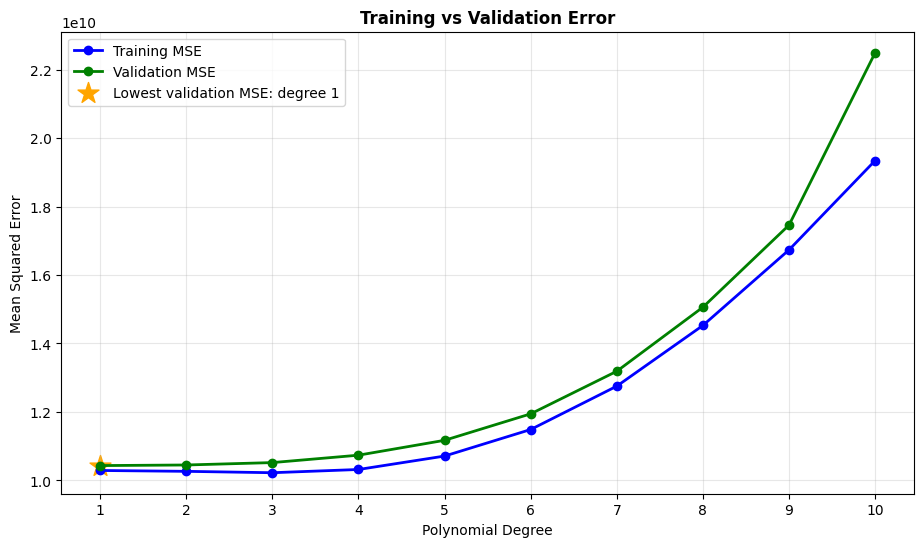

Selected degree: 1


In [21]:
degrees = range(1, 11)
train_errors = []
validation_errors = []

for degree in degrees:
    degree_model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    degree_model.fit(X_train, y_train)

    train_errors.append(mean_squared_error(y_train, degree_model.predict(X_train)))
    validation_errors.append(mean_squared_error(y_validation, degree_model.predict(X_validation)))

best_degree = list(degrees)[np.argmin(validation_errors)]

plt.figure(figsize=(11, 6))
plt.plot(degrees, train_errors, "bo-", linewidth=2, label="Training MSE")
plt.plot(degrees, validation_errors, "go-", linewidth=2, label="Validation MSE")
plt.scatter(best_degree, min(validation_errors), color="orange", marker="*", s=250, label=f"Lowest validation MSE: degree {best_degree}")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Validation Error", fontweight="bold")
plt.xticks(list(degrees))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Selected degree: {best_degree}")

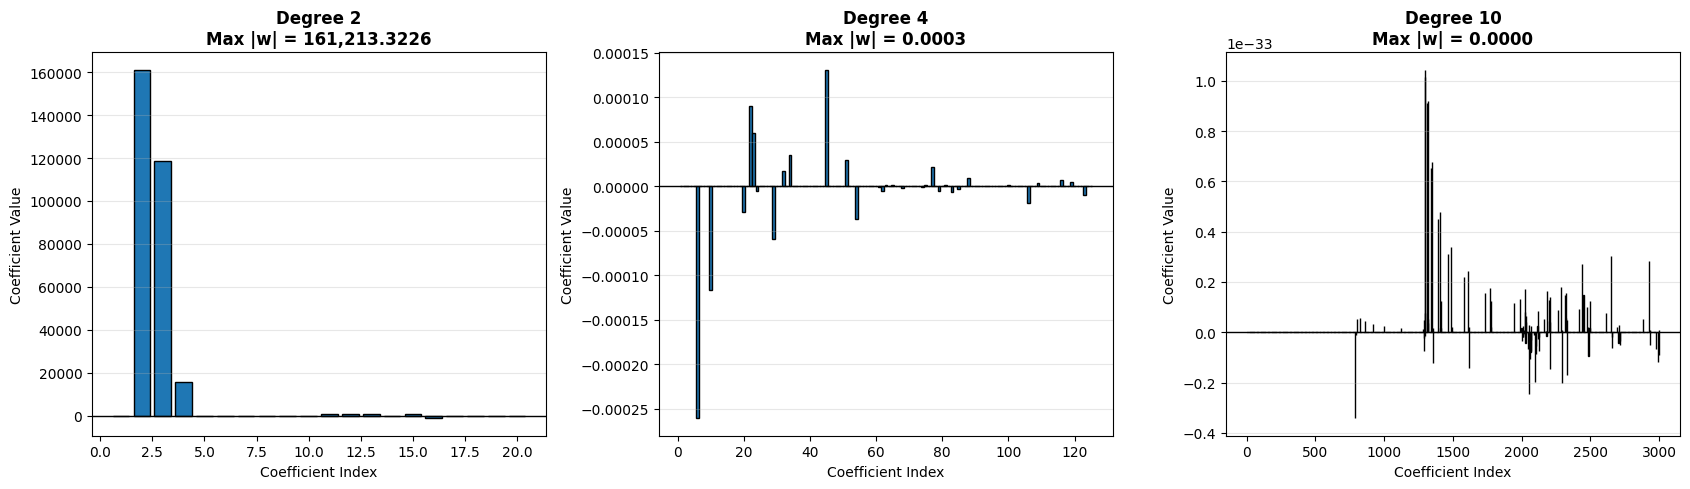

In [26]:
degrees_for_coefficients = [2, 4, 10]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, degree in zip(axes, degrees_for_coefficients):
    features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = features.fit_transform(X_train)

    coefficient_model = LinearRegression()
    coefficient_model.fit(X_train_poly, y_train)

    coefficients = coefficient_model.coef_
    max_coefficient = np.max(np.abs(coefficients))

    ax.bar(range(1, len(coefficients) + 1), coefficients, edgecolor="black")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Degree {degree}\nMax |w| = {max_coefficient:,.4f}", fontweight="bold")
    ax.set_xlabel("Coefficient Index")
    ax.set_ylabel("Coefficient Value")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# degree = 1
degree = 10
# ridge_alpha = 0.01
ridge_alpha = 10

# Both models use the same transformed and scaled features
model_no_regularization = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), LinearRegression())

model_ridge = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), Ridge(alpha=ridge_alpha))

model_no_regularization.fit(X_train, y_train)
model_ridge.fit(X_train, y_train)

no_reg_val_pred = model_no_regularization.predict(X_validation)
ridge_val_pred = model_ridge.predict(X_validation)

print(f"Degree {degree}:")
print(f"No regularization validation MSE: {mean_squared_error(y_validation, no_reg_val_pred):.4f}")
print(f"Ridge validation MSE: {mean_squared_error(y_validation, ridge_val_pred):.4f}")
print(f"No regularization validation R²: {r2_score(y_validation, no_reg_val_pred):.4f}")
print(f"Ridge validation R²: {r2_score(y_validation, ridge_val_pred):.4f}")

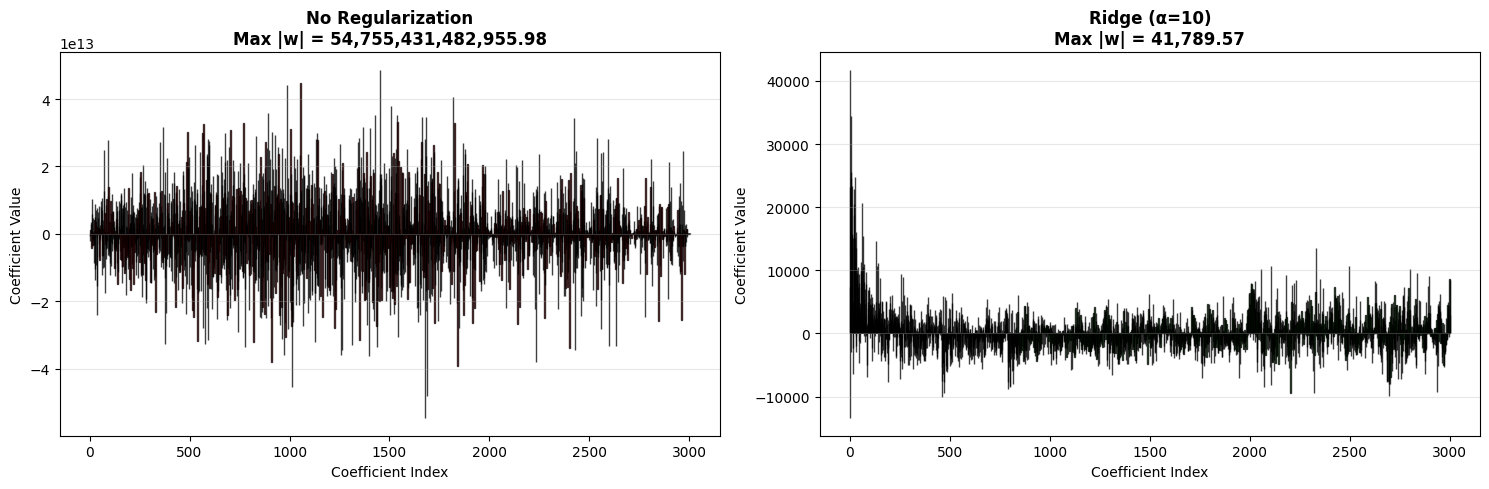

Ridge produced lower validation error on this split.


In [38]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# degree = 1
degree = 10
# ridge_alpha = 0.01
ridge_alpha = 10

# Both models use the same transformed and scaled features
model_no_regularization = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), LinearRegression())

model_ridge = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), Ridge(alpha=ridge_alpha))

model_no_regularization.fit(X_train, y_train)
model_ridge.fit(X_train, y_train)

coefficients_no_reg = model_no_regularization[-1].coef_
coefficients_ridge = model_ridge[-1].coef_

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, len(coefficients_no_reg) + 1), coefficients_no_reg, color="red", alpha=0.75, edgecolor="black")
axes[0].set_title(f"No Regularization\nMax |w| = {np.max(np.abs(coefficients_no_reg)):,.2f}", fontweight="bold")
axes[0].set_xlabel("Coefficient Index")
axes[0].set_ylabel("Coefficient Value")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(range(1, len(coefficients_ridge) + 1), coefficients_ridge, color="green", alpha=0.75, edgecolor="black")
axes[1].set_title(f"Ridge (α={ridge_alpha})\nMax |w| = {np.max(np.abs(coefficients_ridge)):,.2f}", fontweight="bold")
axes[1].set_xlabel("Coefficient Index")
axes[1].set_ylabel("Coefficient Value")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("Ridge produced lower validation error on this split.")

In [ ]:
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]
alpha_validation_errors = []

for alpha in alpha_values:
    alpha_model = make_pipeline(PolynomialFeatures(degree=10, include_bias=False), StandardScaler(), Ridge(alpha=alpha))
    alpha_model.fit(X_train, y_train)

    alpha_validation_errors.append(mean_squared_error(y_validation, alpha_model.predict(X_validation)))

best_alpha = alpha_values[np.argmin(alpha_validation_errors)]

plt.figure(figsize=(10, 6))
plt.semilogx(alpha_values, alpha_validation_errors, "o-", linewidth=2.5, markersize=8)
plt.scatter(best_alpha, min(alpha_validation_errors), color="orange", marker="*", s=250, label=f"Lowest validation MSE: α={best_alpha}")
plt.xlabel("Alpha")
plt.ylabel("Validation MSE")
plt.title("Effect of Ridge Alpha", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Selected alpha for degree {degree}: {best_alpha}")

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

lasso_alpha = 0.001
# lasso_alpha = 10

model_lasso = make_pipeline(PolynomialFeatures(degree=10, include_bias=False), StandardScaler(), Lasso(alpha=lasso_alpha, max_iter=100000))

model_lasso.fit(X_train, y_train)

coefficients_lasso = model_lasso[-1].coef_
zero_count = np.sum(coefficients_lasso == 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, len(coefficients_ridge) + 1), coefficients_ridge, color="blue", alpha=0.75, edgecolor="black")
axes[0].set_title("Ridge: Smooth Shrinkage", fontweight="bold")
axes[0].set_xlabel("Coefficient Index")
axes[0].set_ylabel("Coefficient Value")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(range(1, len(coefficients_lasso) + 1), coefficients_lasso, color="orange", alpha=0.75, edgecolor="black")
axes[1].set_title(f"Lasso: {zero_count} Coefficients Equal Zero", fontweight="bold")
axes[1].set_xlabel("Coefficient Index")
axes[1].set_ylabel("Coefficient Value")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

lasso_val_pred = model_lasso.predict(X_validation)

print(f"Ridge validation MSE: {mean_squared_error(y_validation, ridge_val_pred):.4f}")
print(f"Lasso validation MSE: {mean_squared_error(y_validation, lasso_val_pred):.4f}")
print(f"Lasso coefficients equal to zero: {zero_count}")

In [40]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

candidate_degrees = [2, 4, 6, 9, 10]
candidate_alphas = [0.001, 0.01, 0.1, 1, 10]

models = {
    "Ridge": Ridge,
    "Lasso": Lasso
}

results = {}

for model_name, model_class in models.items():

    validation_results = []

    for degree in candidate_degrees:
        for alpha in candidate_alphas:

            model = make_pipeline(
                PolynomialFeatures(
                    degree=degree,
                    include_bias=False
                ),
                StandardScaler(),
                model_class(alpha=alpha)
            )

            # Train
            model.fit(X_train, y_train)

            # Validation prediction
            y_pred = model.predict(X_validation)

            # Validation MSE
            mse = mean_squared_error(y_validation, y_pred)

            validation_results.append(
                (mse, degree, alpha)
            )

    # Find best combination
    results[model_name] = min(validation_results)


# Display results
for model_name, (mse, degree, alpha) in results.items():

    print(f"\n{model_name} Results")
    print("-" * 30)
    print(f"Best degree: {degree}")
    print(f"Best alpha: {alpha}")
    print(f"Best validation MSE: {mse:,.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.537e+13, tolerance: 3.809e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.510e+13, tolerance: 3.809e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.234e+13, tolerance: 3.809e


Ridge Results
------------------------------
Best degree: 2
Best alpha: 1
Best validation MSE: 10,447,906,606.5259

Lasso Results
------------------------------
Best degree: 2
Best alpha: 10
Best validation MSE: 10,447,423,235.3536


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.004e+12, tolerance: 3.809e+10
  model = cd_fast.enet_coordinate_descent(


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_train_pred = linear_model.predict(X_train)
linear_val_pred = linear_model.predict(X_validation)

print(f"Training MSE: {mean_squared_error(y_train, linear_train_pred):.4f}")
print(f"Validation MSE: {mean_squared_error(y_validation, linear_val_pred):.4f}")
print(f"Validation R²: {r2_score(y_validation, linear_val_pred):.4f}")

Training MSE: 10292121830.7142
Validation MSE: 10435054798.0002
Validation R²: 0.9102


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
scaled_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])
scaled_knn.fit(X_train, y_train)
prediction_with_scaling = scaled_knn.predict(X_validation)

print(f"Validation R² with scaling: {r2_score(y_validation, prediction_with_scaling):.3f}")

Validation R² with scaling: 0.853


In [44]:
from sklearn.metrics import mean_squared_error

k_values = list(range(1, 31))
validation_mse = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    validation_prediction = model.predict(X_validation)
    validation_mse.append(mean_squared_error(y_validation, validation_prediction))

best_k = k_values[np.argmin(validation_mse)]
print(f"Selected K: {best_k}")
print(f"Lowest validation MSE: {min(validation_mse):,.0f}")

Selected K: 15
Lowest validation MSE: 15,819,687,755


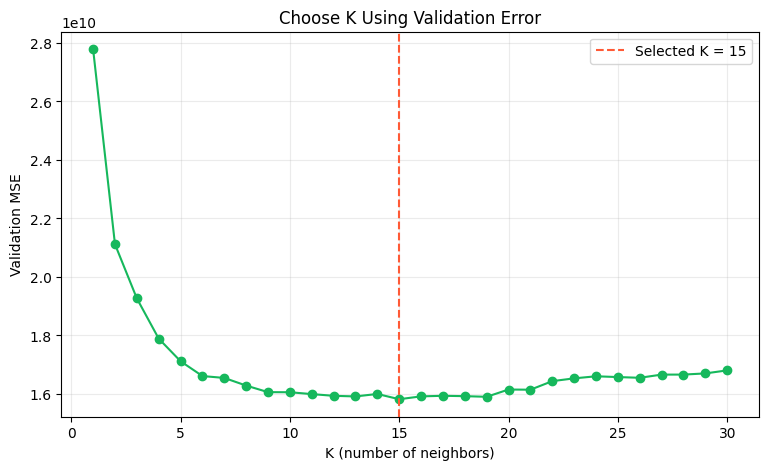

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(k_values, validation_mse, color="#16B85C", marker="o")
plt.axvline(best_k, color="#FF5A36", linestyle="--", label=f"Selected K = {best_k}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Validation MSE")
plt.title("Choose K Using Validation Error")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [46]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Combine Training + Validation data
X_final_train = pd.concat([X_train, X_validation])
y_final_train = pd.concat([y_train, y_validation])

# Create final KNN pipeline
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k))
])

# Train final model on Training + Validation data
final_pipeline.fit(X_final_train, y_final_train)

# Predict on Test data
test_prediction = final_pipeline.predict(X_test)

# Evaluate final model
test_mse = mean_squared_error(y_test, test_prediction)
test_r2 = r2_score(y_test, test_prediction)

print(f"Final K: {best_k}")
print(f"Test MSE: {test_mse:,.0f}")
print(f"Test R²: {test_r2:.3f}")

Final K: 15
Test MSE: 15,329,416,786
Test R²: 0.878


In [50]:
import joblib

joblib.dump(final_pipeline, "house_price_pipeline.joblib")
loaded_pipeline = joblib.load("house_price_pipeline.joblib")

print("Saved and loaded house_price_pipeline.joblib")

Saved and loaded house_price_pipeline.joblib


In [51]:
import pandas as pd

def predict_price(
    avg_area_income,
    avg_area_house_age,
    avg_area_number_of_rooms,
    avg_area_number_of_bedrooms,
    area_population
):
    house = pd.DataFrame([{
        "Avg. Area Income": avg_area_income,
        "Avg. Area House Age": avg_area_house_age,
        "Avg. Area Number of Rooms": avg_area_number_of_rooms,
        "Avg. Area Number of Bedrooms": avg_area_number_of_bedrooms,
        "Area Population": area_population
    }])

    prediction = loaded_pipeline.predict(house)[0]

    return f"Predicted price: ${prediction:,.0f}"

In [52]:
predict_price(20000, 3, 4, 3, 2500)

'Predicted price: $285,057'

In [53]:
def predict_with_neighbors(sq_feet, bedrooms):
    house = np.array([[sq_feet, bedrooms]])
    prediction = loaded_pipeline.predict(house)[0]

    scaler = loaded_pipeline.named_steps["scaler"]
    knn = loaded_pipeline.named_steps["knn"]
    scaled_training = scaler.transform(X_final_train)
    scaled_house = scaler.transform(house)
    _, indices = knn.kneighbors(scaled_house)
    neighbors = indices[0]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(scaled_training[:, 0], scaled_training[:, 1], color="#AAB8C8", alpha=0.55, label="Other houses")
    ax.scatter(scaled_training[neighbors, 0], scaled_training[neighbors, 1], color="#16B85C", s=110, label=f"{best_k} nearest neighbors")
    ax.scatter(scaled_house[0, 0], scaled_house[0, 1], color="#FF5A36", marker="*", s=260, label="New house")

    for index in neighbors:
        ax.plot([scaled_house[0, 0], scaled_training[index, 0]], [scaled_house[0, 1], scaled_training[index, 1]], color="#16B85C", linestyle="--", alpha=0.5)
        ax.annotate(f"${y_final_train[index]:,.0f}", (scaled_training[index, 0], scaled_training[index, 1]), xytext=(5, 6), textcoords="offset points")

    ax.set_xlabel("Standardized square feet")
    ax.set_ylabel("Standardized bedrooms")
    ax.set_title(f"Prediction = average of {best_k} neighbor prices = ${prediction:,.0f}")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()

    return f"Predicted price: ${prediction:,.0f}", fig

In [61]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

model_results = []

# Models you have already trained
models = {
    "Linear Regression": linear_model,
    "Polynomial Regression": poly_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "KNN": final_pipeline
}

for model_name, model in models.items():

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_validation)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_validation, val_pred)
    val_mse = mean_squared_error(y_validation, val_pred)

    model_results.append({
        "Model name": model_name,
        "Train R2": train_r2,
        "Validation R2": val_r2,
        "Validation MSE": val_mse
    })

# Create DataFrame
comparison_table = pd.DataFrame(model_results)

# Sort by Validation R2, highest first
comparison_table = comparison_table.sort_values(
    by="Validation R2",
    ascending=False
).reset_index(drop=True)

# Display
comparison_table

NameError: name 'ridge_model' is not defined

In [54]:
%pip install -q gradio

In [55]:
import gradio as gr

demo = gr.Interface(
    fn=predict_with_neighbors,
    inputs=[
        gr.Slider(500, 3000, value=2000, step=10, label="Square feet"),
        gr.Slider(1, 5, value=3, step=1, label="Bedrooms")
    ],
    outputs=[gr.Textbox(label="Prediction"), gr.Plot(label="Selected neighbors")],
    title="House Price Predictor",
    description=f"Uses the K = {best_k} selected from validation data."
)

In [56]:
import gradio as gr
import pandas as pd

def predict_price(
    avg_area_income,
    avg_area_house_age,
    avg_area_number_of_rooms,
    avg_area_number_of_bedrooms,
    area_population
):
    house = pd.DataFrame([{
        "Avg. Area Income": avg_area_income,
        "Avg. Area House Age": avg_area_house_age,
        "Avg. Area Number of Rooms": avg_area_number_of_rooms,
        "Avg. Area Number of Bedrooms": avg_area_number_of_bedrooms,
        "Area Population": area_population
    }])

    prediction = final_pipeline.predict(house)[0]

    return f"Predicted price: ${prediction:,.0f}"

In [57]:
demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(
            label="Average Area Income",
            value=50000
        ),
        gr.Number(
            label="Average Area House Age",
            value=5
        ),
        gr.Number(
            label="Average Area Number of Rooms",
            value=6
        ),
        gr.Number(
            label="Average Area Number of Bedrooms",
            value=3
        ),
        gr.Number(
            label="Area Population",
            value=30000
        )
    ],
    outputs=gr.Textbox(label="Predicted House Price"),
    title="🏠 House Price Predictor",
    description="Enter the five property/area features to predict the house price."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/08/29 17:32:52 [W] [service.go:132] login to server failed: dial tcp 44.237.78.176:7000: connect: connection refused


<IPython.core.display.Javascript object>

In [58]:
demo.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/08/29 17:33:34 [W] [service.go:132] login to server failed: dial tcp 44.237.78.176:7000: connect: connection refused


<IPython.core.display.Javascript object>

In [59]:
demo.launch(share=False)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>